# Tray Configuration Optimisation

This notebook evaluates how automated-warehouse candidate items can be allocated to tray configurations.

The objective is to translate the feasibility output from the previous notebook into tray-compatible storage logic.

The analysis evaluates:
- tray family definitions
- dimensional compatibility
- compartment compatibility
- tray-space utilisation
- estimated tray requirements
- allocation priorities

The notebook creates a structured tray-allocation and warehouse-slotting logic used for transition evaluation and automated warehouse planning.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

OUTPUT_DIR = Path("../outputs/automated_warehouse")
OUTPUT_DIR.mkdir(exist_ok=True)

DATA_DIR = Path("../data")
INPUT_DIR = Path("../outputs/automated_feasibility")

part_master = pd.read_csv(DATA_DIR / "part_master.csv")

automation_candidates = pd.read_csv(
    INPUT_DIR / "automated_warehouse_candidates.csv"
)

warehouse_definition = pd.read_csv(
    INPUT_DIR / "automated_warehouse_definition.csv"
)

AUTO_WAREHOUSE = dict(
    zip(
        warehouse_definition["Parameter"],
        warehouse_definition["Value"]
    )
)

TOTAL_AVAILABLE_TRAYS = int(
    float(AUTO_WAREHOUSE["Tray_Count"])
)

TOTAL_AVAILABLE_VOLUME_CM3 = (
    float(AUTO_WAREHOUSE["Max_Storable_Volume_m3"]) *
    1_000_000
)

## Tray Configuration
The automated warehouse uses trays with fixed external dimensions and configurable internal compartments.

Tray logic:
- B: small-parts/minuteria tray
- D: medium compartment tray
- E: larger square-compartment tray
- F: large two-compartment tray
- Ver: full-tray / oversized compartment
- G and H: intermediate tray configurations used for items that do not fit efficiently into the standard E or F logic

The useful height is kept at 175 mm to avoid occupying two tray pitch positions.

In [42]:
TRAY_HEIGHT_MM = 175

tray_configurations = pd.DataFrame([
    {
        "Tray_Type": "B",
        "Compartments_Per_Tray": 50,
        "Compartment_Width_mm": 160,
        "Compartment_Depth_mm": 160,
        "Compartment_Height_mm": TRAY_HEIGHT_MM
    },
    {
        "Tray_Type": "D",
        "Compartments_Per_Tray": 16,
        "Compartment_Width_mm": 400,
        "Compartment_Depth_mm": 200,
        "Compartment_Height_mm": TRAY_HEIGHT_MM
    },
    {
        "Tray_Type": "E",
        "Compartments_Per_Tray": 8,
        "Compartment_Width_mm": 400,
        "Compartment_Depth_mm": 400,
        "Compartment_Height_mm": TRAY_HEIGHT_MM
    },
    {
        "Tray_Type": "F",
        "Compartments_Per_Tray": 2,
        "Compartment_Width_mm": 800,
        "Compartment_Depth_mm": 800,
        "Compartment_Height_mm": TRAY_HEIGHT_MM
    },
    {
        "Tray_Type": "G",
        "Compartments_Per_Tray": 4,
        "Compartment_Width_mm": 800,
        "Compartment_Depth_mm": 400,
        "Compartment_Height_mm": TRAY_HEIGHT_MM
    },
    {
        "Tray_Type": "H",
        "Compartments_Per_Tray": 8,
        "Compartment_Width_mm": 800,
        "Compartment_Depth_mm": 200,
        "Compartment_Height_mm": TRAY_HEIGHT_MM
    },
    {
        "Tray_Type": "Ver",
        "Compartments_Per_Tray": 1,
        "Compartment_Width_mm": 1600,
        "Compartment_Depth_mm": 800,
        "Compartment_Height_mm": TRAY_HEIGHT_MM
    }
])

# theoretical usable storage volume for one compartment
tray_configurations["Compartment_Volume_cm3"] = (
    tray_configurations["Compartment_Width_mm"] *
    tray_configurations["Compartment_Depth_mm"] *
    tray_configurations["Compartment_Height_mm"] /
    1000
)

# total theoretical tray storage capacity
tray_configurations["Tray_Theoretical_Volume_cm3"] = (
    tray_configurations["Compartment_Volume_cm3"] *
    tray_configurations["Compartments_Per_Tray"]
)

tray_configurations

,Tray_Type,Compartments_Per_Tray,Compartment_Width_mm,Compartment_Depth_mm,Compartment_Height_mm,Compartment_Volume_cm3,Tray_Theoretical_Volume_cm3
0,B,50,160,160,175,4480.0,224000.0
1,D,16,400,200,175,14000.0,224000.0
2,E,8,400,400,175,28000.0,224000.0
3,F,2,800,800,175,112000.0,224000.0
4,G,4,800,400,175,56000.0,224000.0
5,H,8,800,200,175,28000.0,224000.0
6,Ver,1,1600,800,175,224000.0,224000.0


## Tray Configuration Visualisation

In [43]:
def draw_tray(tray_type, tray_width=1600, tray_depth=800, rows=1, cols=1):
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.add_patch(
        patches.Rectangle(
            (0, 0),
            tray_width,
            tray_depth,
            fill=False,
            linewidth=2
        )
    )

    cell_width = tray_width / cols
    cell_depth = tray_depth / rows

    for r in range(rows):
        for c in range(cols):
            ax.add_patch(
                patches.Rectangle(
                    (c * cell_width, r * cell_depth),
                    cell_width,
                    cell_depth,
                    fill=False,
                    linewidth=1
                )
            )
            ax.text(
                c * cell_width + cell_width / 2,
                r * cell_depth + cell_depth / 2,
                f"{int(cell_width)}x{int(cell_depth)}",
                ha="center",
                va="center",
                fontsize=8
            )

    ax.set_xlim(0, tray_width)
    ax.set_ylim(0, tray_depth)
    ax.set_aspect("equal")
    ax.set_title(f"Tray {tray_type} Configuration")
    ax.set_xlabel("Width (mm)")
    ax.set_ylabel("Depth (mm)")

    plt.show()

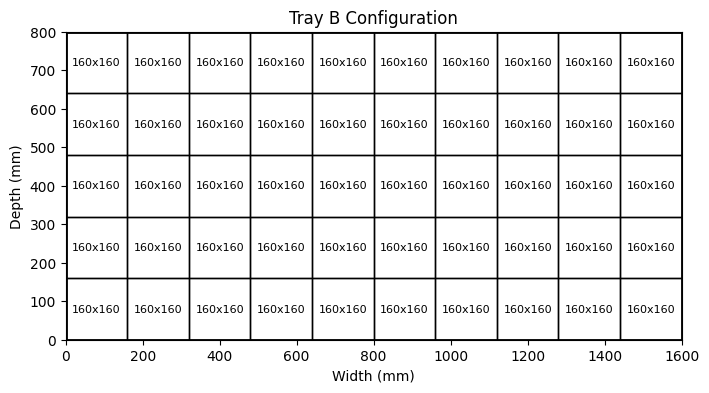

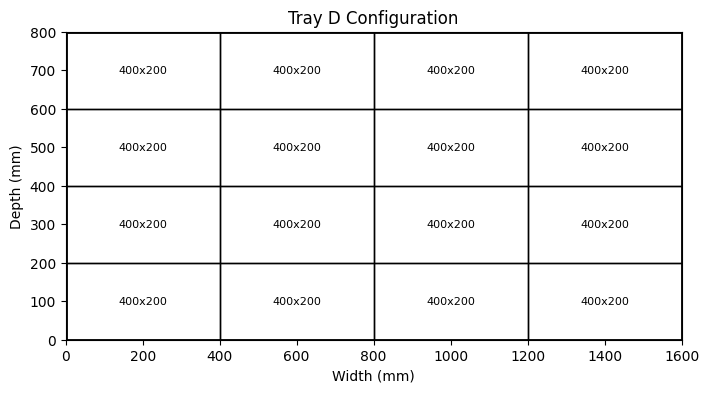

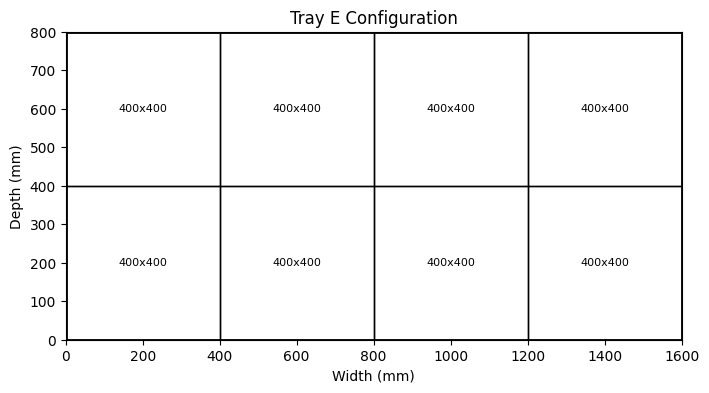

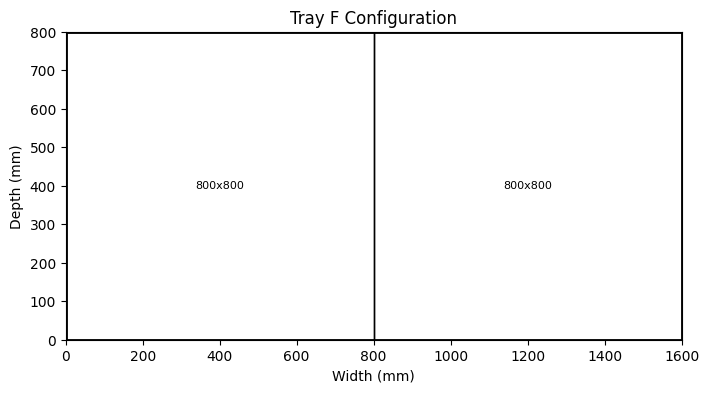

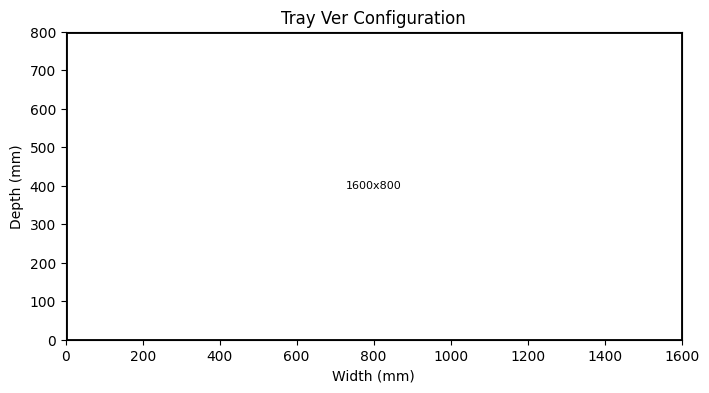

In [44]:
draw_tray("B", rows=5, cols=10)   # 50 spaces
draw_tray("D", rows=4, cols=4)    # 16 spaces
draw_tray("E", rows=2, cols=4)    # 8 spaces
draw_tray("F", rows=1, cols=2)    # 2 spaces
draw_tray("Ver", rows=1, cols=1)  # full tray

## Automated Warehouse Dimensioning Logic

The automated warehouse is not intended to absorb the entire spare-parts population.

Instead, the warehouse is dimensioned to support:
- operationally relevant inventory
- high-movement spare parts
- physically compatible items
- improved picking accessibility
- higher storage density
- future operational scalability

The sizing logic therefore focuses on:
- movement concentration
- dimensional compatibility
- tray allocation feasibility
- warehouse saturation
- operational throughput considerations

The analyses evaluate how much operational warehouse activity can be absorbed by the automated system while maintaining remaining future capacity for additional inventory migration and warehouse expansion.

## Candidate Preparation

The candidate list from notebook 08 is prepared for tray-configuration matching.

Each item is compared with available tray-compartment dimensions and assigned to the smallest compatible tray type.

In [45]:
tray_priority = ["B", "D", "E", "H", "G", "F", "Ver"]

tray_configurations["Tray_Type"] = pd.Categorical(
    tray_configurations["Tray_Type"],
    categories=tray_priority,
    ordered=True
)

tray_configurations = tray_configurations.sort_values("Tray_Type")

automation_candidates = automation_candidates.copy()

# estimated occupied storage volume for each SKU
automation_candidates["Required_Volume_cm3"] = (
    automation_candidates["Unit_Volume_cm3"] *
    automation_candidates["Stock_Qty"]
)

## Tray Compatibility Function

The compatibility logic evaluates whether each item can physically fit inside a tray compartment while allowing footprint rotation within the compartment geometry.

The item is allowed to rotate inside the compartment footprint.  
Height must remain within the allowed useful tray height.

In [46]:
def item_fits_compartment(item, tray):
    item_x = item["Dim_X_mm"]
    item_y = item["Dim_Y_mm"]
    item_z = item["Dim_Z_mm"]

    comp_x = tray["Compartment_Width_mm"]
    comp_y = tray["Compartment_Depth_mm"]
    comp_z = tray["Compartment_Height_mm"]

    # item can be rotated within the tray compartment footprint
    footprint_fit = (
        ((item_x <= comp_x) and (item_y <= comp_y)) or
        ((item_x <= comp_y) and (item_y <= comp_x))
    )

    # item must remain within useful tray height
    height_fit = item_z <= comp_z

    return footprint_fit and height_fit

## Assign Smallest Compatible Tray Type

Each candidate item is assigned to the smallest tray configuration that can physically contain it.

This follows the storage-density logic used in tray-based warehouse allocation: use the smallest compatible compartment before allocating larger tray spaces.

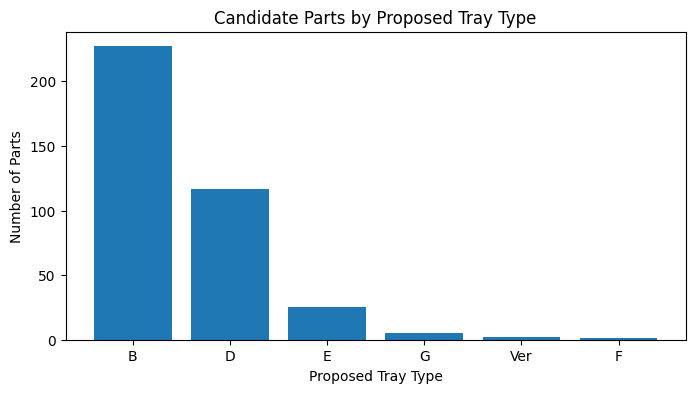

,Proposed_Tray_Type,Parts,Total_Movement_Lines,Total_Required_Volume_cm3,Avg_Unit_Volume_cm3
0,B,227,1989,773063,507.58
1,D,117,2301,2123719,2023.74
2,E,25,274,878275,4182.68
4,G,5,221,659194,15067.00
5,Ver,2,528,3543485,48258.00
3,F,1,28,247167,27463.00


In [47]:
def assign_tray_type(item, tray_table):
    for _, tray in tray_table.iterrows():
        if item_fits_compartment(item, tray):
            return tray["Tray_Type"]
    return "No compatible tray"

automation_candidates["Proposed_Tray_Type"] = automation_candidates.apply(
    assign_tray_type,
    axis=1,
    tray_table=tray_configurations
)

tray_assignment_summary = (
    automation_candidates
    .groupby("Proposed_Tray_Type")
    .agg(
        Parts=("Part_ID", "count"),
        Total_Movement_Lines=("Movement_Lines_36M", "sum"),
        Total_Required_Volume_cm3=("Required_Volume_cm3", "sum"),
        Avg_Unit_Volume_cm3=("Unit_Volume_cm3", "mean")
    )
    .round(2)
    .reset_index()
    .sort_values("Parts", ascending=False)
)

plt.figure(figsize=(8,4))

plt.bar(
    tray_assignment_summary["Proposed_Tray_Type"],
    tray_assignment_summary["Parts"]
)

plt.xlabel("Proposed Tray Type")
plt.ylabel("Number of Parts")
plt.title("Candidate Parts by Proposed Tray Type")

plt.show()

tray_assignment_summary

## Estimated Tray Requirements

This section estimates how many trays are required by tray type.

The estimate is based on the number of candidate parts assigned to each tray family and the number of compartments available per tray.

This is a planning-level tray-capacity estimate used to evaluate warehouse saturation and tray-family allocation before detailed slot sequencing.

The allocation estimate assumes one primary compartment allocation per SKU.

The objective of this notebook is not to simulate detailed bin-packing optimisation, but to estimate:
- tray-family requirements
- warehouse saturation
- storage-allocation structure
- operational tray distribution

Detailed compartment sequencing would require a lower-level warehouse slotting model.

In [48]:
tray_requirements = (
    automation_candidates
    .merge(
        tray_configurations[
            [
                "Tray_Type",
                "Compartments_Per_Tray",
                "Compartment_Volume_cm3",
                "Tray_Theoretical_Volume_cm3"
            ]
        ],
        left_on="Proposed_Tray_Type",
        right_on="Tray_Type",
        how="left"
    )
)

# simplified planning assumption:
# one primary compartment allocated per SKU
tray_requirements["Estimated_Compartments_Required"] = 1

tray_requirements["Estimated_Compartments_Required"] = (
    tray_requirements["Estimated_Compartments_Required"]
    .clip(lower=1)
)

tray_requirement_summary = (
    tray_requirements
    .groupby("Proposed_Tray_Type")
    .agg(
        Parts=("Part_ID", "count"),
        Compartments_Per_Tray=("Compartments_Per_Tray", "first"),
        Estimated_Compartments_Required=("Estimated_Compartments_Required", "sum"),
        Total_Required_Volume_cm3=("Required_Volume_cm3", "sum"),
        Total_Movement_Lines=("Movement_Lines_36M", "sum"),
        Compartment_Volume_cm3=("Compartment_Volume_cm3", "first")
    )
    .reset_index()
)

# estimated tray count required by tray family
tray_requirement_summary["Estimated_Trays_Required"] = np.ceil(
    tray_requirement_summary["Estimated_Compartments_Required"] /
    tray_requirement_summary["Compartments_Per_Tray"]
)

tray_requirement_summary["Estimated_Available_Tray_Volume_cm3"] = (
    tray_requirement_summary["Estimated_Trays_Required"] *
    tray_requirement_summary["Compartments_Per_Tray"] *
    tray_requirement_summary["Compartment_Volume_cm3"]
)

# estimated occupied compartment utilisation
tray_requirement_summary["Estimated_Compartment_Utilisation_%"] = (
    tray_requirement_summary["Total_Required_Volume_cm3"] /
    tray_requirement_summary["Estimated_Available_Tray_Volume_cm3"] * 100
).round(2)

tray_requirement_summary = (
    tray_requirement_summary
    .round(2)
    .sort_values("Estimated_Trays_Required", ascending=False)
)

tray_requirement_summary

,Proposed_Tray_Type,Parts,Compartments_Per_Tray,Estimated_Compartments_Required,Total_Required_Volume_cm3,Total_Movement_Lines,Compartment_Volume_cm3,Estimated_Trays_Required,Estimated_Available_Tray_Volume_cm3,Estimated_Compartment_Utilisation_%
1,D,117,16,117,2123719,2301,14000.0,8.0,1792000.0,118.51
0,B,227,50,227,773063,1989,4480.0,5.0,1120000.0,69.02
2,E,25,8,25,878275,274,28000.0,4.0,896000.0,98.02
4,G,5,4,5,659194,221,56000.0,2.0,448000.0,147.14
5,Ver,2,1,2,3543485,528,224000.0,2.0,448000.0,790.96
3,F,1,2,1,247167,28,112000.0,1.0,224000.0,110.34


## Tray Utilisation Review

This section reviews estimated volume utilisation by tray type.

Low utilisation may indicate inefficient allocation, oversized compartments, or items that require special handling.

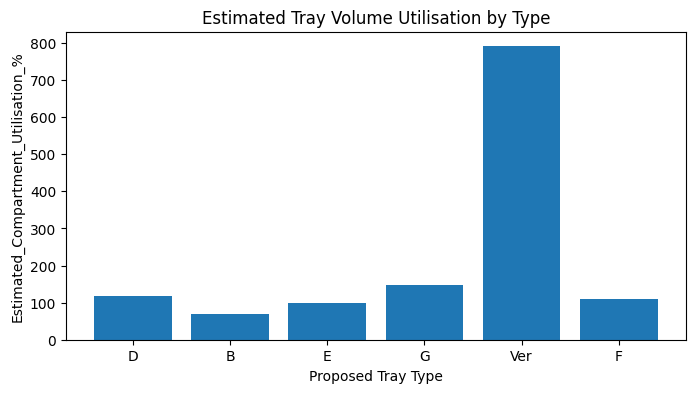

1    118.51
0     69.02
2     98.02
4    147.14
5    790.96
3    110.34
Name: Estimated_Compartment_Utilisation_%, dtype: float64

In [49]:
plt.figure(figsize=(8,4))

plt.bar(
    tray_requirement_summary["Proposed_Tray_Type"],
    tray_requirement_summary["Estimated_Compartment_Utilisation_%"]
)

plt.xlabel("Proposed Tray Type")
plt.ylabel("Estimated_Compartment_Utilisation_%")
plt.title("Estimated Tray Volume Utilisation by Type")

plt.show()

tray_requirement_summary["Estimated_Compartment_Utilisation_%"]

## Movement Priority within Tray Types

Once items are assigned to tray families, movement intensity is used to prioritise the sequence of tray creation.

High-movement items should be allocated earlier and, later in the transition evaluation, positioned closer to the picking bays where possible.

In [50]:
tray_movement_priority = (
    automation_candidates
    .groupby(["Proposed_Tray_Type", "Movement_Class"])
    .agg(
        Parts=("Part_ID", "count"),
        Total_Movement_Lines=("Movement_Lines_36M", "sum")
    )
    .round(2)
    .reset_index()
    .sort_values(
        ["Proposed_Tray_Type", "Total_Movement_Lines"],
        ascending=[True, False]
    )
)

tray_movement_priority

,Proposed_Tray_Type,Movement_Class,Parts,Total_Movement_Lines
1,B,A+,3,736
2,B,B,17,549
3,B,C,67,405
0,B,A,3,175
4,B,D,109,120
5,B,NC,28,4
7,D,A+,4,998
8,D,B,22,740
6,D,A,4,364
9,D,C,23,134


## Candidate Allocation Table

This table is the detailed item-level output of the tray-configuration step.

It contains the proposed tray type for each candidate item and will be used in the warehouse transition evaluation.

In [51]:
candidate_tray_allocation = tray_requirements[
    [
        "Part_ID",
        "Part_Name",
        "Part_Category",
        "Movement_Class",
        "Movement_Lines_36M",
        "Manual_Location",
        "UDC_Type",
        "Dim_X_mm",
        "Dim_Y_mm",
        "Dim_Z_mm",
        "Unit_Volume_cm3",
        "Stock_Qty",
        "Required_Volume_cm3",
        "Proposed_Tray_Type",
        "Compartments_Per_Tray",
        "Compartment_Volume_cm3"
    ]
].copy()

candidate_tray_allocation = candidate_tray_allocation.sort_values(
    ["Proposed_Tray_Type", "Movement_Lines_36M"],
    ascending=[True, False]
)

## Operational Slotting Logic

After tray-family assignment, tray locations inside the automated warehouse can be prioritised according to movement intensity.

High-movement trays should be positioned closer to the picking bays to reduce:
- trasloelevatore travel distance
- positioning time
- acceleration/deceleration losses
- operator waiting time

Lower-movement trays can be allocated farther from the bays because their operational access frequency is lower.

This follows the operational logic described in the original warehouse-engineering evaluation.

In [52]:
slotting_priority = (
    candidate_tray_allocation
    .groupby("Proposed_Tray_Type")
    .agg(
        Parts=("Part_ID", "count"),
        Total_Movement_Lines=("Movement_Lines_36M", "sum")
    )
    .reset_index()
    .sort_values("Total_Movement_Lines", ascending=False)
)

# higher-movement tray families receive higher slotting priority
slotting_priority["Suggested_Position_Priority"] = range(
    1,
    len(slotting_priority) + 1
)

slotting_priority

,Proposed_Tray_Type,Parts,Total_Movement_Lines,Suggested_Position_Priority
1,D,117,2301,1
0,B,227,1989,2
5,Ver,2,528,3
2,E,25,274,4
4,G,5,221,5
3,F,1,28,6


## Tray Configuration Summary

This section consolidates the tray-configuration planning outputs.

In [53]:
tray_configuration_kpis = pd.DataFrame({
    "Metric": [
        "Candidate parts allocated",
        "Items without compatible tray",
        "Estimated trays required",
        "Available trays in automated warehouse",
        "Estimated tray usage %",
        "Total movement lines covered"
    ],
    "Value": [
        candidate_tray_allocation[
            candidate_tray_allocation["Proposed_Tray_Type"] != "No compatible tray"
        ]["Part_ID"].nunique(),
        candidate_tray_allocation[
            candidate_tray_allocation["Proposed_Tray_Type"] == "No compatible tray"
        ]["Part_ID"].nunique(),
        tray_requirement_summary["Estimated_Trays_Required"].sum(),
        TOTAL_AVAILABLE_TRAYS,
        round(tray_requirement_summary["Estimated_Trays_Required"].sum() / TOTAL_AVAILABLE_TRAYS * 100,
        2),
        candidate_tray_allocation["Movement_Lines_36M"].sum()
    ]
})

tray_configuration_kpis

,Metric,Value
0,Candidate parts allocated,377.00
1,Items without compatible tray,0.00
2,Estimated trays required,22.00
3,Available trays in automated warehouse,53.00
4,Estimated tray usage %,41.51
5,Total movement lines covered,5341.00


## Automated Warehouse Capacity Review

In [54]:
# total estimated trays required by allocation logic
used_trays = tray_requirement_summary["Estimated_Trays_Required"].sum()

# estimated allocated storage volume
used_volume = tray_requirement_summary[
    "Estimated_Available_Tray_Volume_cm3"
].sum()

# percentage of candidate operational movement covered
movement_capture_pct = (
    candidate_tray_allocation["Movement_Lines_36M"].sum() /
    automation_candidates["Movement_Lines_36M"].sum()
) * 100

warehouse_capacity_summary = pd.DataFrame({
    "Metric": [
        "Available trays",
        "Used trays",
        "Remaining trays",
        "Tray saturation %",
        "Available warehouse volume cm3",
        "Used warehouse volume cm3",
        "Warehouse volume saturation %",
        "Movement lines captured %",
        "Candidate parts allocated"
    ],
    "Value": [
        TOTAL_AVAILABLE_TRAYS,
        used_trays,
        TOTAL_AVAILABLE_TRAYS - used_trays,
        round(used_trays / TOTAL_AVAILABLE_TRAYS * 100, 2),
        TOTAL_AVAILABLE_VOLUME_CM3,
        round(used_volume, 2),
        round(used_volume / TOTAL_AVAILABLE_VOLUME_CM3 * 100, 2),
        round(movement_capture_pct, 2),
        candidate_tray_allocation["Part_ID"].nunique()
    ]
})

warehouse_capacity_summary

,Metric,Value
0,Available trays,53.00
1,Used trays,22.00
2,Remaining trays,31.00
3,Tray saturation %,41.51
4,Available warehouse volume cm3,12060000.00
5,Used warehouse volume cm3,4928000.00
6,Warehouse volume saturation %,40.86
7,Movement lines captured %,100.00
8,Candidate parts allocated,377.00


## Warehouse Saturation Interpretation

The estimated tray usage and occupied warehouse volume indicate that the automated warehouse maintains significant remaining capacity after the first migration phase.

This is operationally important because automated warehouse projects are typically dimensioned to:
- support future inventory migration
- absorb future SKU growth
- maintain operational flexibility
- avoid early warehouse saturation

The remaining capacity also allows future optimisation of tray allocation and movement prioritisation without requiring immediate warehouse expansion.

## Export Tray Configuration Outputs

The tray-configuration outputs are exported for the warehouse-transition evaluation and Power BI reporting.

In [55]:
# outputs used by downstream transition-evaluation notebooks
tray_configurations.to_csv(
    OUTPUT_DIR / "tray_configurations.csv",
    index=False
)

candidate_tray_allocation.to_csv(
    OUTPUT_DIR / "candidate_tray_allocation.csv",
    index=False
)

tray_assignment_summary.to_csv(
    OUTPUT_DIR / "tray_assignment_summary.csv",
    index=False
)

tray_requirement_summary.to_csv(
    OUTPUT_DIR / "tray_requirement_summary.csv",
    index=False
)

tray_movement_priority.to_csv(
    OUTPUT_DIR / "tray_movement_priority.csv",
    index=False
)

tray_configuration_kpis.to_csv(
    OUTPUT_DIR / "tray_configuration_kpis.csv",
    index=False
)

warehouse_capacity_summary.to_csv(
    OUTPUT_DIR / "warehouse_capacity_summary.csv",
    index=False
)

slotting_priority.to_csv(
    OUTPUT_DIR / "slotting_priority.csv",
    index=False
)

## Operational Observations

The tray-configuration analysis translates automated-warehouse feasibility into storage-allocation logic.

The results support:
- identification of the most suitable tray family for each candidate item
- estimation of tray requirements by tray type
- review of expected tray-volume utilisation
- movement-priority planning within tray families
- preparation of the final warehouse transition evaluation

This notebook creates the tray-family allocation and storage-distribution logic used in the final warehouse-transition evaluation and operational warehouse redesign assessment.